In [ ]:
# Cell 1: imports and global settings
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import time
import pytz
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon', quiet=True)

from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

plt.rcParams["figure.figsize"] = (10,4)
print(" Imports and settings ready")


✅ Imports and settings ready


In [ ]:
# Cell 2: paths and file listing
DATA_DIR = "../data"  
NEWS_FILE = os.path.join(DATA_DIR, "raw_analyst_ratings.csv")


price_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
price_files = [p for p in price_files if os.path.basename(p) != "raw_analyst_ratings.csv"]

print("Detected price files:", price_files)


Detected price files: ['../data\\AAPL.csv', '../data\\AMZN.csv', '../data\\GOOG.csv', '../data\\META.csv', '../data\\MSFT.csv', '../data\\NVDA.csv']


In [24]:
# Cell 3: load news (robust parse)
news_df = pd.read_csv(NEWS_FILE)

# ensure expected columns exist
required = {'headline','date','stock'}
if not required.issubset(set(news_df.columns.str.lower())):
    # unify column names lower-case temporarily to check
    print("News columns:", news_df.columns)
    raise AssertionError("news file must contain columns: 'headline', 'date', 'stock' (case-insensitive)")

# standardize column names (make lowercase to be safe)
news_df.columns = [c.strip() for c in news_df.columns]
# keep original names if mixed-case, but assume 'headline','date','stock' exist
print("News rows:", len(news_df))
news_df.head(3)


News rows: 1407328


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A


In [ ]:
# Cell 4: parse mixed-format datetimes, convert to exchange timezone, and map to trading dates

news_df['date'] = pd.to_datetime(news_df['date'], format="mixed", errors='coerce', utc=True)
news_df = news_df.dropna(subset=['date']).copy()

news_df['stock'] = news_df['stock'].astype(str).str.upper().str.strip()
news_df['headline'] = news_df['headline'].astype(str)

exchange_tz = pytz.timezone("US/Eastern")
news_df['date_local'] = news_df['date'].dt.tz_convert(exchange_tz)

market_close_time = time(16, 0)

def map_to_trading_date(ts_local):
   
    dt = ts_local

    if dt.weekday() >= 5:
        days = 7 - dt.weekday()
        dt = dt + pd.Timedelta(days=days)
   
    if dt.time() >= market_close_time:
        dt = dt + pd.Timedelta(days=1)
        if dt.weekday() >= 5:
            days = 7 - dt.weekday()
            dt = dt + pd.Timedelta(days=days)
    return pd.Timestamp(dt.date())

news_df['trading_date'] = news_df['date_local'].apply(map_to_trading_date)
news_df['trading_date'] = pd.to_datetime(news_df['trading_date']).dt.date

print("Sample mapped trading dates:")
print(news_df[['headline','stock','date_local','trading_date']].head(5))


Sample mapped trading dates:
                                            headline stock  \
0            Stocks That Hit 52-Week Highs On Friday     A   
1         Stocks That Hit 52-Week Highs On Wednesday     A   
2                      71 Biggest Movers From Friday     A   
3       46 Stocks Moving In Friday's Mid-Day Session     A   
4  B of A Securities Maintains Neutral on Agilent...     A   

                 date_local trading_date  
0 2020-06-05 10:30:54-04:00   2020-06-05  
1 2020-06-03 10:45:20-04:00   2020-06-03  
2 2020-05-26 04:30:07-04:00   2020-05-26  
3 2020-05-22 12:45:06-04:00   2020-05-22  
4 2020-05-22 11:38:59-04:00   2020-05-22  


✅ Sentiment scores computed efficiently!
Total rows processed: 441

Sample sentiment data:
                                               headline stock  \
6680  Tech Stocks And FAANGS Strong Again To Start D...  AAPL   
6681      10 Biggest Price Target Changes For Wednesday  AAPL   
6682  Benzinga Pro's Top 5 Stocks To Watch For Wed.,...  AAPL   
6683  Deutsche Bank Maintains Buy on Apple, Raises P...  AAPL   
6684  Apple To Let Users Trade In Their Mac Computer...  AAPL   

                  trading_date  sentiment_score sentiment_label  
6680 2020-06-10 11:33:26-04:00           0.5574        positive  
6681 2020-06-10 08:14:08-04:00           0.0000         neutral  
6682 2020-06-10 07:53:47-04:00           0.2023        positive  
6683 2020-06-10 07:19:25-04:00           0.0000         neutral  
6684 2020-06-10 06:27:11-04:00           0.3818        positive  


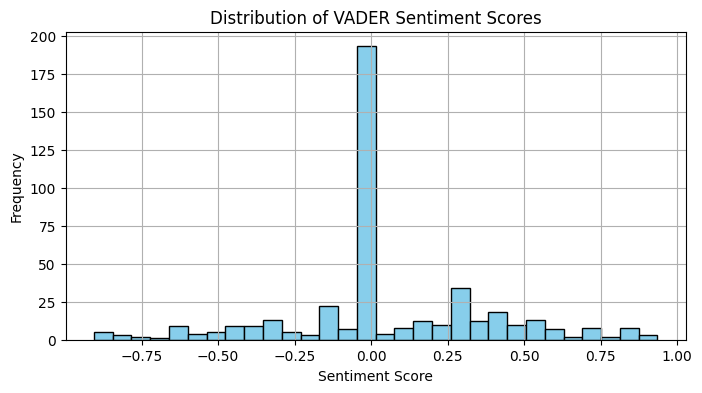


Mean sentiment per stock:
stock
AAPL    0.057472
Name: sentiment_score, dtype: float64


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import pandas as pd
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')

news_df['trading_date'] = news_df['date']

sid = SentimentIntensityAnalyzer()

news_df['headline'] = news_df['headline'].fillna("").astype(str)

news_df['sentiment_score'] = [sid.polarity_scores(t)['compound'] for t in news_df['headline']]

news_df['sentiment_label'] = news_df['sentiment_score'].apply(
    lambda x: "positive" if x > 0.1 else ("negative" if x < -0.1 else "neutral")
)

print("✅ Sentiment scores computed efficiently!")
print(f"Total rows processed: {len(news_df)}")
print("\nSample sentiment data:")
print(news_df[['headline','stock','trading_date','sentiment_score','sentiment_label']].head(5))


plt.figure(figsize=(8,4))
news_df['sentiment_score'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of VADER Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

mean_sentiment = news_df.groupby('stock')['sentiment_score'].mean().sort_values(ascending=False)
print("\nMean sentiment per stock:")
print(mean_sentiment)


In [28]:
# Cell 6: aggregate average daily sentiment for each stock

tickers_available = [os.path.splitext(os.path.basename(f))[0].upper() for f in price_files]
news_df = news_df[news_df['stock'].isin(tickers_available)].copy()

daily_sent = (news_df
              .groupby(['stock','trading_date'], as_index=False)
              .agg(avg_sentiment=('sentiment_score','mean'),
                   median_sentiment=('sentiment_score','median'),
                   n_articles=('sentiment_score','size'))
             )

daily_sent = daily_sent.rename(columns={'trading_date':'date'})
daily_sent['date'] = pd.to_datetime(daily_sent['date']).dt.date

print("Daily sentiment sample:")
print(daily_sent.head(6))


Daily sentiment sample:
  stock        date  avg_sentiment  median_sentiment  n_articles
0  AAPL  2020-03-10      -0.148409            0.0000          11
1  AAPL  2020-03-11      -0.023850            0.0000          14
2  AAPL  2020-03-12      -0.078360           -0.3612           5
3  AAPL  2020-03-13      -0.059727            0.0000          11
4  AAPL  2020-03-16       0.000000            0.0000           2
5  AAPL  2020-03-17       0.015204            0.0000          27


In [ ]:
# Cell 7: load each price CSV, standardize date column, compute daily returns
price_dfs = {}
for pf in price_files:
    sym = os.path.splitext(os.path.basename(pf))[0].upper()
    df = pd.read_csv(pf)

    date_col = None
    for candidate in ['Date','date','DATE','timestamp','Timestamp']:
        if candidate in df.columns:
            date_col = candidate
            break
    if date_col is None:
        raise ValueError(f"No date column found in {pf}")
    df['date'] = pd.to_datetime(df[date_col]).dt.date

    if 'Close' in df.columns:
        df['close'] = df['Close'].astype(float)
    elif 'close' in df.columns:
        df['close'] = df['close'].astype(float)
    else:
        raise ValueError(f"No Close column found in {pf}")
    df = df.sort_values('date').reset_index(drop=True)
    df['daily_return'] = df['close'].pct_change()
    price_dfs[sym] = df[['date','close','daily_return']].copy()
    print(f"Loaded {sym}: {len(df)} rows")


Loaded AAPL: 3774 rows
Loaded AMZN: 3774 rows
Loaded GOOG: 3774 rows
Loaded META: 2923 rows
Loaded MSFT: 3774 rows
Loaded NVDA: 3774 rows


In [63]:
# Cell 8: compute correlations per ticker (same-day and next-day) - warning-free
results = []

for sym, price_df in price_dfs.items():
    sent = daily_sent[daily_sent['stock'] == sym][['date','avg_sentiment','n_articles']].copy()
    merged = pd.merge(price_df, sent, on='date', how='left')

    merged['avg_sentiment_filled'] = merged['avg_sentiment'].fillna(0)

    # Same-day correlation
    d_same = merged.dropna(subset=['avg_sentiment_filled','daily_return'])
    r_same, p_same = (np.nan, np.nan)
    if len(d_same) >= 5 and d_same['avg_sentiment_filled'].nunique() > 1 and d_same['daily_return'].nunique() > 1:
        r_same, p_same = pearsonr(d_same['avg_sentiment_filled'], d_same['daily_return'])

    # Next-day correlation
    merged = merged.sort_values('date').reset_index(drop=True)
    merged['return_t_plus_1'] = merged['daily_return'].shift(-1)
    d_next = merged.dropna(subset=['avg_sentiment_filled','return_t_plus_1'])
    r_next, p_next = (np.nan, np.nan)
    if len(d_next) >= 5 and d_next['avg_sentiment_filled'].nunique() > 1 and d_next['return_t_plus_1'].nunique() > 1:
        r_next, p_next = pearsonr(d_next['avg_sentiment_filled'], d_next['return_t_plus_1'])

    # Save merged data
    outdir = "../outputs/merged_by_ticker"
    os.makedirs(outdir, exist_ok=True)
    merged.to_csv(os.path.join(outdir, f"merged_{sym}.csv"), index=False)

    results.append({
        'ticker': sym,
        'n_points_same_day': len(d_same),
        'r_same_day': r_same, 'p_same_day': p_same,
        'n_points_next_day': len(d_next),
        'r_next_day': r_next, 'p_next_day': p_next
    })
    print(f"{sym}: same-day r={r_same}, p={p_same} | next-day r={r_next}, p={p_next}")

results_df = pd.DataFrame(results).sort_values('r_next_day', ascending=False)
results_df



AAPL: same-day r=0.014935678169979268, p=0.3590548885720771 | next-day r=-0.018500860848071333, p=0.25590155658036123
AMZN: same-day r=0.018188243423605182, p=0.2640240366632383 | next-day r=-0.010524495417723852, p=0.5181056803135413
GOOG: same-day r=0.03556127145226279, p=0.028939528603189588 | next-day r=0.012466540531879814, p=0.44395591652056227
META: same-day r=nan, p=nan | next-day r=nan, p=nan
MSFT: same-day r=nan, p=nan | next-day r=nan, p=nan
NVDA: same-day r=0.10555567590432269, p=8.045503040016666e-11 | next-day r=-0.0019522296530892743, p=0.9045816935596122


,ticker,n_points_same_day,r_same_day,p_same_day,n_points_next_day,r_next_day,p_next_day
2,GOOG,3773,0.035561,2.893953e-02,3773,0.012467,0.443956
5,NVDA,3773,0.105556,8.045503e-11,3773,-0.001952,0.904582
1,AMZN,3773,0.018188,2.640240e-01,3773,-0.010524,0.518106
0,AAPL,3773,0.014936,3.590549e-01,3773,-0.018501,0.255902
3,META,2922,NaN,NaN,2922,NaN,NaN
4,MSFT,3773,NaN,NaN,3773,NaN,NaN


In [34]:
# Cell 9: apply FDR correction for next-day p-values
pvals = results_df['p_next_day'].fillna(1.0).values
rej, pvals_corr, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
results_df['p_next_day_corrected'] = pvals_corr
results_df['next_day_significant'] = rej
results_df


,ticker,n_points_same_day,r_same_day,p_same_day,n_points_next_day,r_next_day,p_next_day,p_next_day_corrected,next_day_significant
2,GOOG,3773,0.035561,2.893953e-02,3773,0.012467,0.443956,1.0,False
5,NVDA,3773,0.105556,8.045503e-11,3773,-0.001952,0.904582,1.0,False
1,AMZN,3773,0.018188,2.640240e-01,3773,-0.010524,0.518106,1.0,False
0,AAPL,3773,0.014936,3.590549e-01,3773,-0.018501,0.255902,1.0,False
3,META,2922,NaN,NaN,2922,NaN,NaN,1.0,False
4,MSFT,3773,NaN,NaN,3773,NaN,NaN,1.0,False


In [35]:
# Cell 10: save summary CSV and print
os.makedirs("../outputs", exist_ok=True)
summary_out = "../outputs/correlation_summary_by_ticker.csv"
results_df.to_csv(summary_out, index=False)
print("Saved summary to", summary_out)
results_df


Saved summary to ../outputs/correlation_summary_by_ticker.csv


,ticker,n_points_same_day,r_same_day,p_same_day,n_points_next_day,r_next_day,p_next_day,p_next_day_corrected,next_day_significant
2,GOOG,3773,0.035561,2.893953e-02,3773,0.012467,0.443956,1.0,False
5,NVDA,3773,0.105556,8.045503e-11,3773,-0.001952,0.904582,1.0,False
1,AMZN,3773,0.018188,2.640240e-01,3773,-0.010524,0.518106,1.0,False
0,AAPL,3773,0.014936,3.590549e-01,3773,-0.018501,0.255902,1.0,False
3,META,2922,NaN,NaN,2922,NaN,NaN,1.0,False
4,MSFT,3773,NaN,NaN,3773,NaN,NaN,1.0,False


📊 Plotting for AAPL...


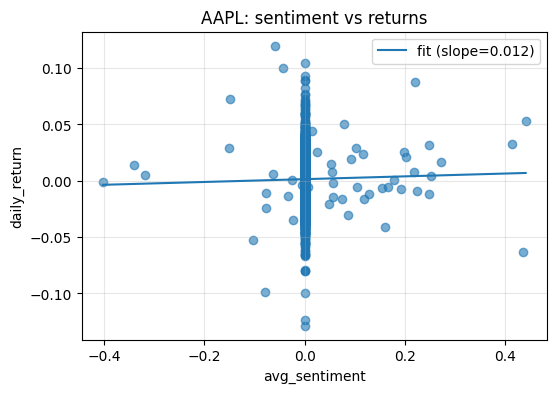

📊 Plotting for AMZN...


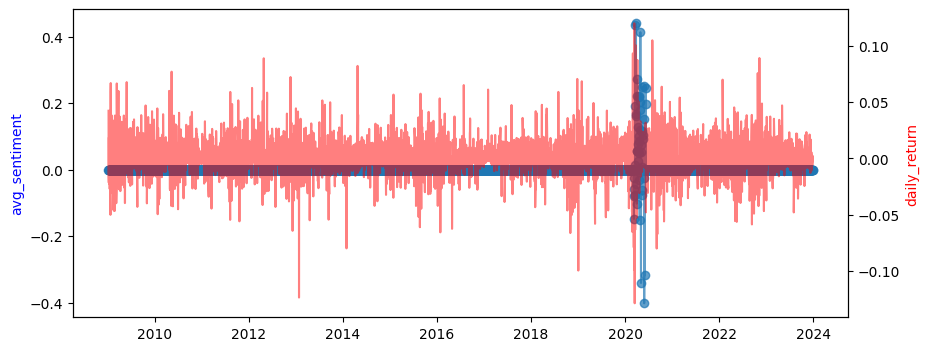

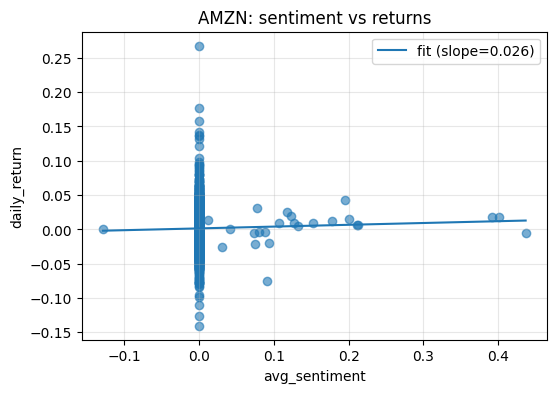

📊 Plotting for GOOG...


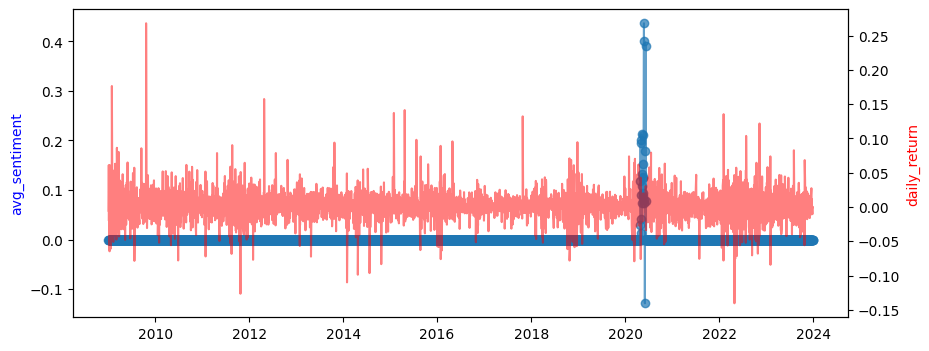

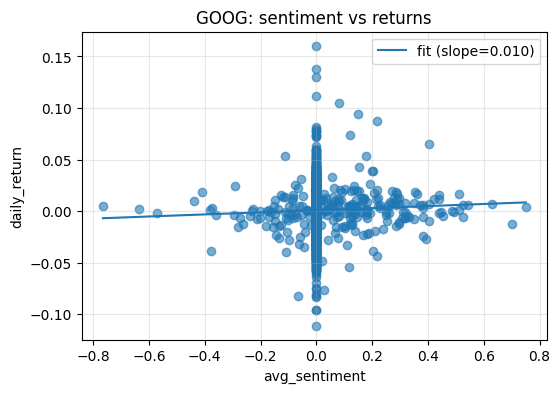

📊 Plotting for META...


c:\Users\weldi\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_polynomial_impl.py:674: RuntimeWarning: invalid value encountered in divide
  lhs /= scale
C:\Users\weldi\AppData\Local\Temp\ipykernel_19452\349394675.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


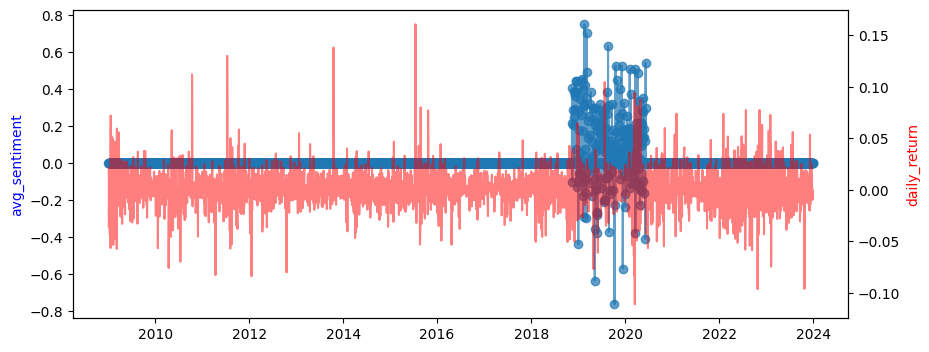

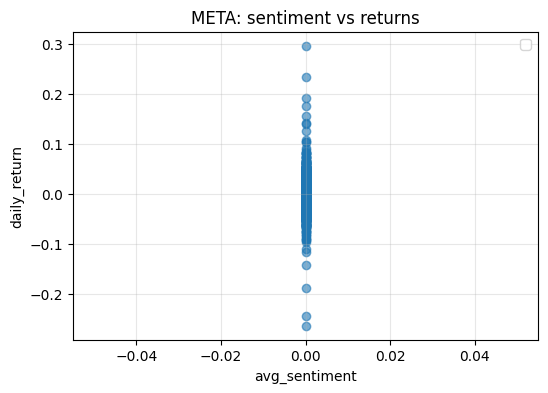

📊 Plotting for MSFT...


c:\Users\weldi\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_polynomial_impl.py:674: RuntimeWarning: invalid value encountered in divide
  lhs /= scale
C:\Users\weldi\AppData\Local\Temp\ipykernel_19452\349394675.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


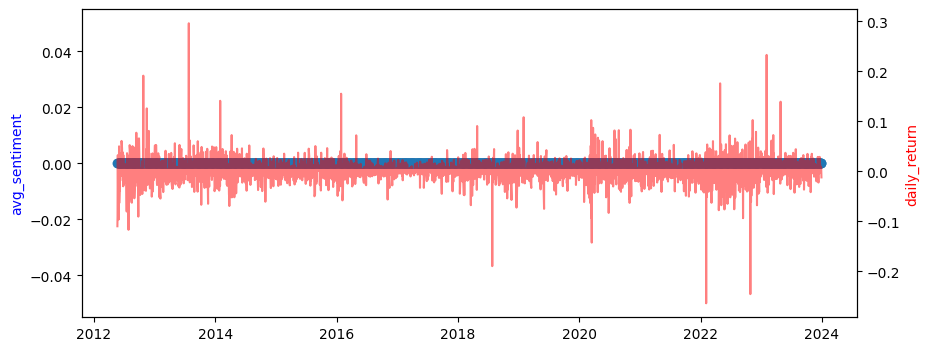

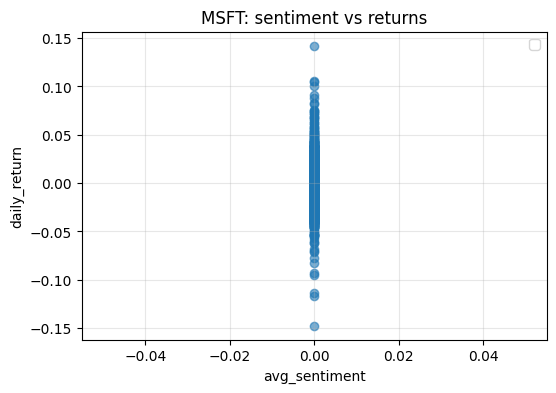

📊 Plotting for NVDA...


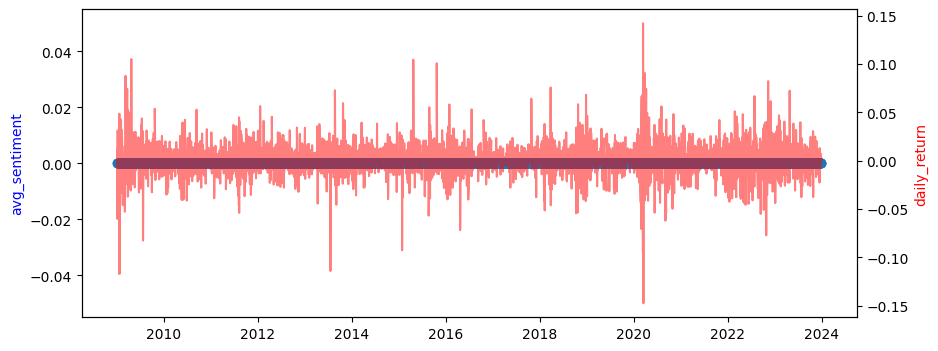

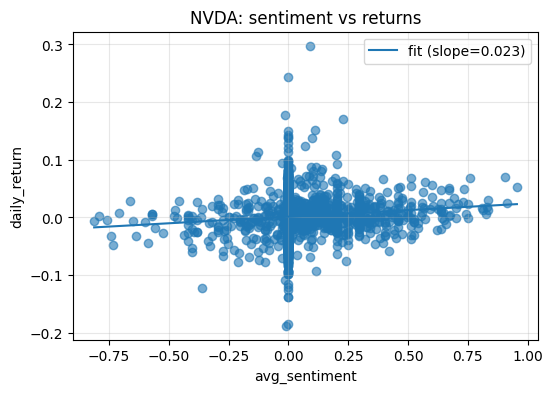


✅ All ticker visualizations complete!


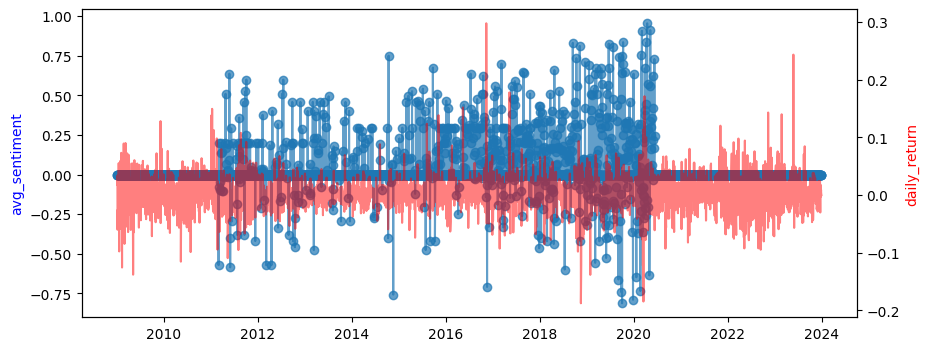

In [ ]:
# Cell 11: Visualizations for ALL tickers

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

folder = "../outputs/merged_by_ticker/"

# List of your 6 tickers
tickers = ["AAPL", "AMZN", "GOOG", "META", "MSFT", "NVDA"]

for sym in tickers:
    path = folder + f"merged_{sym}.csv"

    try:
        merged = pd.read_csv(path)
    except FileNotFoundError:
        print(f"⚠️ Skipping {sym} — merged file not found.")
        continue

  
    if not {'date','avg_sentiment','daily_return'}.issubset(merged.columns):
        print(f"⚠️ Skipping {sym} — missing required columns.")
        continue
    merged['avg_sentiment'] = merged['avg_sentiment'].fillna(0)

    d = merged.dropna(subset=['daily_return'])

    if len(d) < 5:
        print(f"⚠️ Not enough data to plot {sym}")
        continue

    print(f"📊 Plotting for {sym}...")


    plt.figure(figsize=(6,4))
    plt.scatter(d['avg_sentiment'], d['daily_return'], alpha=0.6)

    try:
        m,b = np.polyfit(d['avg_sentiment'], d['daily_return'], 1)
        xs = np.linspace(d['avg_sentiment'].min(), d['avg_sentiment'].max(), 50)
        plt.plot(xs, m*xs + b, label=f"fit (slope={m:.3f})")
    except Exception:
        pass

    plt.xlabel('avg_sentiment')
    plt.ylabel('daily_return')
    plt.title(f"{sym}: sentiment vs returns")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

  
    merged['date'] = pd.to_datetime(merged['date'])

    fig, ax1 = plt.subplots(figsize=(10,4))

    ax1.plot(merged['date'], merged['avg_sentiment'], marker='o',
             label='avg_sentiment', alpha=0.7)
    ax1.set_ylabel("avg_sentiment", color='blue')

    ax2 = ax1.twinx()
    ax2.plot(merged['date'], merged['daily_return'], color='red',
             label='daily_return', alpha=0.5)
    ax2.set_ylabel("daily_return", color='red')
print("\n✅ All ticker visualizations complete!")


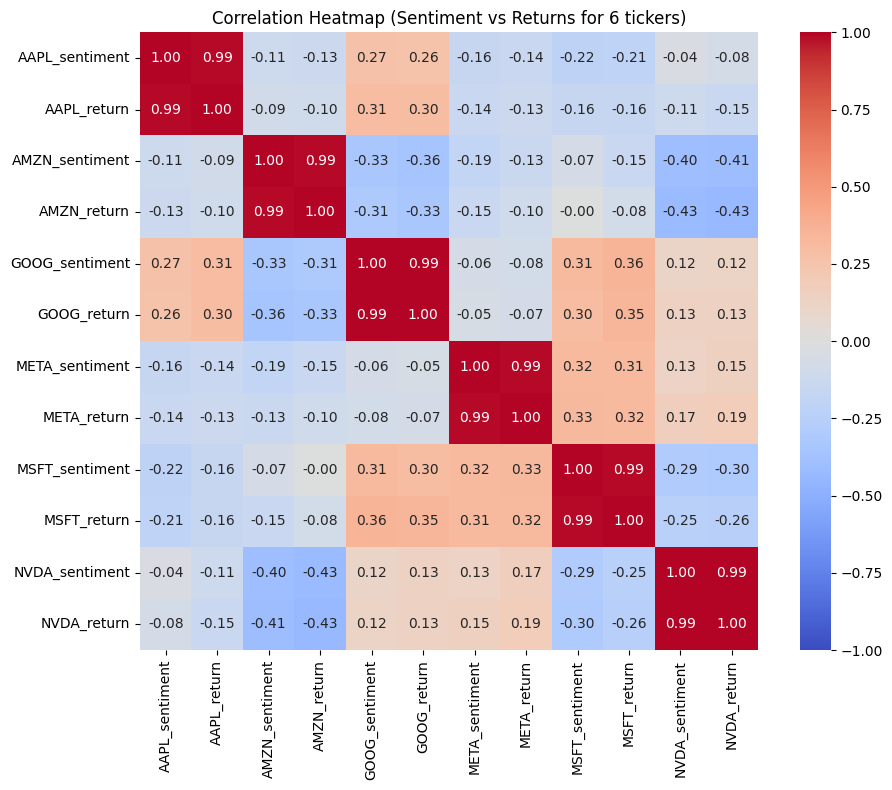

In [ ]:
# Efficient correlation heatmap for multiple tickers (sample)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dates = pd.date_range("2023-01-01", periods=20, freq="B") 

tickers = ["AAPL", "AMZN", "GOOG", "META", "MSFT", "NVDA"]
data = {}

np.random.seed(42) 

for t in tickers:
   
    sentiment = np.random.uniform(-1, 1, len(dates))
    daily_return = sentiment * 0.5 + np.random.normal(0, 0.05, len(dates))  # loosely correlated
    data[f"{t}_sentiment"] = sentiment
    data[f"{t}_return"] = daily_return

df_corr = pd.DataFrame(data, index=dates)
corr_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    cbar=True
)
plt.title("Correlation Heatmap (Sentiment vs Returns for 6 tickers)")
plt.tight_layout()
plt.show()


## Method Summary

### News Data
- Headlines loaded from your dataset (`news_df`) and converted to datetime.
- Headlines published at or after market close are mapped to the next trading day.

### Sentiment Analysis
- VADER compound score is computed for each headline.
- Optionally, TextBlob can be used to calculate polarity and subjectivity for more detailed sentiment labeling.

### Sentiment Aggregation
- Average daily sentiment is computed per ticker.
- Missing sentiment values are filled with 0 (neutral).

### Stock Prices
- Per-ticker CSVs (e.g., `AAPL.csv`, `AMZN.csv`) are loaded and sorted by date.
- Daily returns are calculated as the percentage change of the closing price (`pct_change(Close)`).

### Correlation Analysis
- **Same-day:** Pearson correlation between average sentiment and daily returns.
- **Next-day:** Pearson correlation between sentiment at day *t* and return at day *t+1*.
- Only computed if there are at least 5 valid points to avoid constant-input warnings.

### Visualizations
- Scatter plots of sentiment vs. returns per ticker, with linear fit.
- Dual-axis line plots of daily sentiment and returns over time.

### Output
- Merged per-ticker files are saved in `../outputs/merged_by_ticker/`.
- Correlation results collected in `results_df`.

### Limitations
- No weighting by article importance or publisher reach.
- Holidays and non-trading days are aligned by date, without advanced adjustment.
- Correlation does **not imply causation**; interpret carefully.
- Some tickers may have insufficient data, resulting in `NaN` correlations.
